# Horse racing data analysis

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rc
from package import algorithm

file_name = 'horse_racing_data.csv'
processed_data = 'horse_racing_data(preprocessing).csv'
current_path = os.getcwd()
data_path = current_path + '\\' + 'data' + '\\' + 'horse racing data' + '\\' 
image_path = current_path + '\\' + 'image' + '\\' + 'horse racing' + '\\' 

name_columns = 'Horse'
covariate_columns = ['Act. Wt.','Dr.','Win Odds']

### Data preprocessing

Drop Nan

In [2]:
df = pd.read_csv(data_path + file_name,index_col='race_id')
#covariate_columns = ['Act. Wt.','Declar. Horse Wt.','Dr.','Win Odds']
covariate_columns = ['Act. Wt.','Dr.','Win Odds']
NaN_columns = covariate_columns+['Pla.']
for covariate in NaN_columns:
    df[covariate] = pd.to_numeric(df[covariate], errors='coerce')
    df = df.dropna(subset=[covariate])


Select suitable matches and players

In [3]:
def delete_matches(df,m_lower=0,m_upper=100):
    df = df.copy()
    i = 0
    indexes = []
    for index in df.index.unique():
        m = df[df.index == index].shape[0]
        if m >= m_lower and m <= m_upper:
            i += 1
        else:
            indexes.append(index)
    df = df.drop(index = indexes)
    return df,i

def delete_players(df,d_min=0,name = 'Horse'):
    counts = df[name].value_counts()
    values_to_keep = counts[counts >= d_min].index
    df = df[df[name].isin(values_to_keep)]
    return df,len(values_to_keep)

def select(df,m_lower=0,m_upper=100,d_min=0,name = 'Horse'):
    NN = len(df.index.unique())
    nn = len(df[name].value_counts())
    while True:
        print('-'*10)
        print(f'The number of matches: {NN}')
        print(f'The number of horses: {nn}')
        df,N = delete_matches(df,m_lower,m_upper)
        df,n = delete_players(df,d_min)
        if NN == N and nn == n:
            break
        else:
            NN = N
            nn = n
    return df,n,N

In [4]:
m_lower = 4
m_upper = 14
d_min = 25
df,n,N = select(df,m_lower,m_upper,d_min)

----------
The number of matches: 18644
The number of horses: 11256
----------
The number of matches: 18644
The number of horses: 3969
----------
The number of matches: 17915
The number of horses: 3872
----------
The number of matches: 17681
The number of horses: 3828
----------
The number of matches: 17521
The number of horses: 3800
----------
The number of matches: 17418
The number of horses: 3768
----------
The number of matches: 17277
The number of horses: 3740
----------
The number of matches: 17178
The number of horses: 3725
----------
The number of matches: 17124
The number of horses: 3717
----------
The number of matches: 17090
The number of horses: 3709
----------
The number of matches: 17059
The number of horses: 3701
----------
The number of matches: 17027
The number of horses: 3693
----------
The number of matches: 16998
The number of horses: 3689
----------
The number of matches: 16984
The number of horses: 3687
----------
The number of matches: 16974
The number of horses:

Normalization

In [5]:
# Actual Weight
df['Act. Wt.'] = np.log(df['Act. Wt.'])
mean_A = df['Act. Wt.'].mean()
std_A = df['Act. Wt.'].std()
df['Act. Wt.'] = (df['Act. Wt.'] - mean_A) / std_A
# Draw
df['Dr.']
for index in df.index.unique():
    df.loc[index,'Dr.'] = pd.Series(df.loc[index,'Dr.']/max(df.loc[index,'Dr.'])).astype(float)
# Belief
for index in df.index.unique():
    t = df.loc[index,'Win Odds']
    df.loc[index,'Win Odds'] = np.log((1 / t) / np.sum(1 / t))

In [6]:
df.to_csv(data_path+'horse_racing_data(preprocessing).csv')

### Data Analysis

Construct T and X

In [13]:
df = pd.read_csv(data_path + processed_data,index_col='race_id')

horseID = {}
T = []
X = []
for index in df.index.unique():
    x = np.array(df[covariate_columns].loc[index])
    X.append(x)

    t = []
    horses_name = df[name_columns].loc[index].tolist()
    for i,horse_name in enumerate(horses_name):
        added_horse = horseID.keys()
        if horse_name in added_horse:
            horseID[horse_name]['times'] += 1
        else:
            n = len(added_horse)
            horseID[horse_name] = {'ID':n,'times':1,'place':[],'covariate':[]}
        horseID[horse_name]['place'].append(i+1)
        horseID[horse_name]['covariate'].append(x[i])
        t.append(horseID[horse_name])
    T.append(t)
n = len(horseID)

C:\Users\13299\AppData\Local\Temp\ipykernel_13444\3954975628.py:1: DtypeWarning: Columns (8) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(data_path + processed_data,index_col='race_id')


PlusDC

In [11]:
u_plusDC,v_plusDC = algorithm.AM(T,X,n,E=1e-3,Eu=1e-8,Ev=1e-12,I=50)
l_plusDC = algorithm.multi_likelihood(T,X,u_plusDC,v_plusDC)
print(l_plusDC)

-11.129466684793744


PL

In [12]:
u_pl,v_pl = algorithm.AM(T,X,n,P=True,detail=True)
l_pl = algorithm.multi_likelihood(T,X,u_pl,v_pl)
print(l_pl)

-11.682460589191065


In [55]:

sorted_indices = np.argsort(-u_pl)  
ranks_pl = np.empty_like(sorted_indices)
ranks_pl[sorted_indices] = np.arange(1, len(u_pl) + 1) 
np.argmin(ranks_pl)

3671

In [57]:
plusDC_top10 = np.argsort(u_plusDC)[-10:][::-1]
u_t10_plusDC = u_plusDC[plusDC_top10]
i = 0
for index, uu in zip(plusDC_top10,u_t10_plusDC):
    i += 1
    horse_name = [key for key, value in horseID.items() if value['ID'] == index][0]
    id = horseID[horse_name]['ID']
    times = horseID[horse_name]['times']
    mean_place = np.mean(horseID[horse_name]['place'])
    mean_covariate = np.mean(horseID[horse_name]['covariate'],axis=0)
    uu_pl = u_pl[id]
    print('-'*10+f'Ranking:{i}'+'-'*10)
    print(f'Horse:{horse_name}, ID:{id}')
    print(f'Race:{times}, Ranking_PL:{ranks_pl[id]}, Mean_Place:{mean_place}')
    print(f'Score_PlusDC:{uu},score_PL:{uu_pl}')
    print(f'Mean_covariate:{mean_covariate}')

----------Ranking:1----------
Horse:GOLDEN SIXTY (C238), ID:3671
Race:27, Ranking_PL:1, Mean_Place:1.2962962962962963
Score_PlusDC:2.850219397942345,score_PL:5.5022171177005985
Mean_covariate:[ 0.35015637  0.50233491 -0.43790907]
----------Ranking:2----------
Horse:EXULTANT (B101), ID:3666
Race:28, Ranking_PL:2, Mean_Place:1.5357142857142858
Score_PlusDC:2.7795035571534026,score_PL:4.626401185751201
Mean_covariate:[ 0.66943104  0.70475011 -0.76118695]
----------Ranking:3----------
Horse:TOURBILLON DIAMOND (E054), ID:3579
Race:25, Ranking_PL:4, Mean_Place:2.52
Score_PlusDC:2.4339473280436597,score_PL:3.908470303675119
Mean_covariate:[ 0.45545924  0.54690387 -1.7328305 ]
----------Ranking:4----------
Horse:BEAUTY GENERATION (V380), ID:3665
Race:31, Ranking_PL:3, Mean_Place:2.064516129032258
Score_PlusDC:2.2827696485202313,score_PL:4.2365206725737075
Mean_covariate:[ 0.73431977  0.5101113  -1.09247468]
----------Ranking:5----------
Horse:SEASONS BLOOM (V410), ID:3664
Race:27, Ranking_PL:7

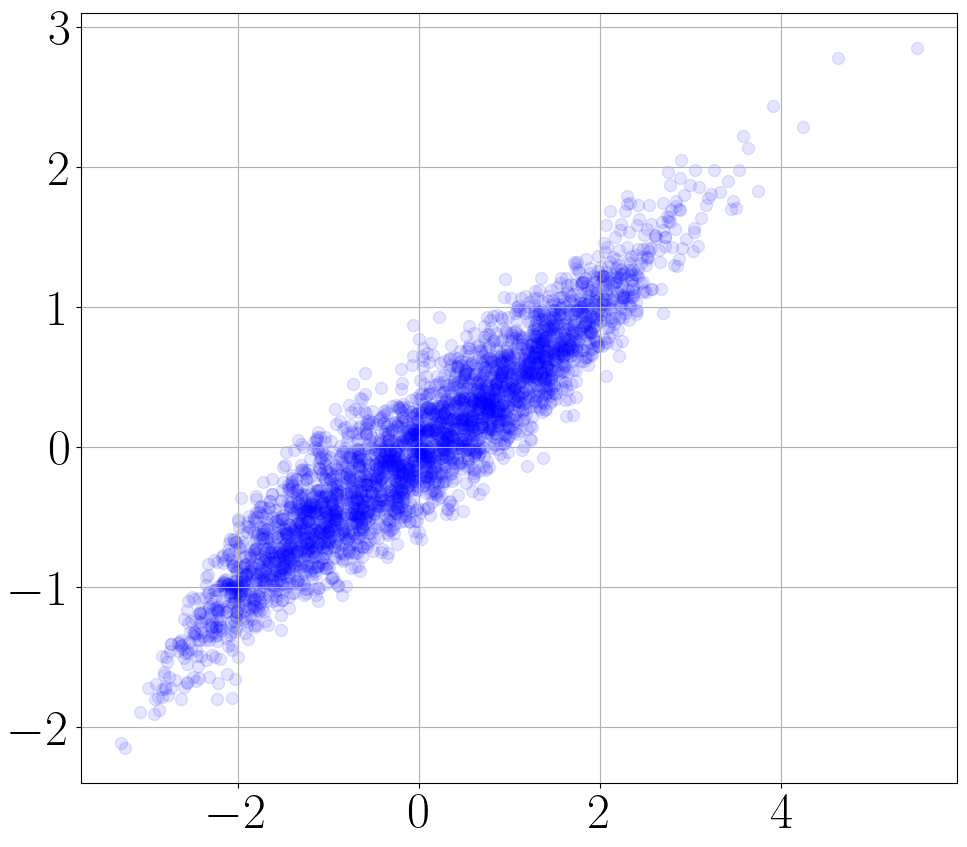

In [58]:
fig,ax = plt.subplots(figsize=(11.3,10))
ax.scatter(u_pl,u_plusDC,s = 75,alpha=0.1,c='blue')
sz = 36
plt.xticks(size = sz)
plt.yticks(size = sz)

rc('text', usetex=True)
rc('font', family='serif')
plt.grid()

plt.savefig(image_path+'score.pdf')
plt.show()